In [28]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from dotenv import load_dotenv
import os
load_dotenv()

True

In [7]:
arxiv_wrapper = ArxivAPIWrapper(top_k_results=2)
wiki_wrapper = WikipediaAPIWrapper(top_k_results=2)

arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_wrapper)

tavily_tool = TavilySearchResults()

arxiv_tool, wiki_tool, tavily_tool

(ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000)),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Ansh Lulla\\VS-Code\\LangGraph_tutorial\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))))

In [8]:
tools = [arxiv_tool, wiki_tool, tavily_tool]
tools

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000)),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Ansh Lulla\\VS-Code\\LangGraph_tutorial\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))]

In [11]:
llm = ChatGroq(model="qwen-qwq-32b", temperature=0.4)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001E3B3BA0550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E3B3BA2710>, model_name='qwen-qwq-32b', temperature=0.4, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [31]:
llm = llm.bind_tools(tools)
llm

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001E3B3BA0550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E3B3BA2710>, model_name='qwen-qwq-32b', temperature=0.4, model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv', 'description': 'A wrapper around Arxiv.org Useful for when you need to answer questions about Physics, Mathematics, Computer Science, Quantitative Biology, Quantitative Finance, Statistics, Electrical Engineering, and Economics from scientific articles on arxiv.org. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'wikipedia', 'description': 'A wrapper around Wikipedia. Useful for when you need to answer general questions about people, places, co

In [32]:
llm.invoke("What is the latest news on Ind Pak") # does not give a response, instead returns a tool call

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_czx4', 'function': {'arguments': '{"query": "latest news India Pakistan relations"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 182, 'prompt_tokens': 403, 'total_tokens': 585, 'completion_time': 0.444680877, 'prompt_time': 0.05218584, 'queue_time': 0.289317568, 'total_time': 0.496866717}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_3796682456', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-18ef1e9c-3584-418f-89bb-9eb1d4ade558-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest news India Pakistan relations'}, 'id': 'call_czx4', 'type': 'tool_call'}], usage_metadata={'input_tokens': 403, 'output_tokens': 182, 'total_tokens': 585})

In [33]:
tavily_tool.invoke("What is the latest news on Ind Pak")[:2]

[{'title': 'Pahalgam attack LIVE: BSF lodges protest with Pakistan Rangers on ...',
  'url': 'https://www.thehindu.com/news/national/pahalgam-terror-attack-jammu-and-kashmir-loc-tensions-live-updates-april-29-2025/article69503715.ece',
  'content': 'The Secretary-General “remains deeply concerned about the situation between India and Pakistan. He strongly urges both Governments to exercise maximum restraint and avoid any escalation,” a statement by the office of his spokesperson said Monday (April 28, 2025). [...] Earlier, such inadvertent crossings on either side were resolved quickly, but this time the Pakistani side has remained “non-committal” on the whereabouts and the date of return of the jawan which could be due to rising India-Pakistan tensions after the Pahalgam attack, they said.\n\nMeanwhile, Prime Minister Narendra Modi chaired a meeting with the top defence establishment, including Defence Minister Rajnath Singh, National Security Advisor Ajit Doval and the chiefs of the 

In [46]:
# State schema
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [47]:
# Node Definitions
def tool_calling_llm(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [48]:
# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

In [50]:
# Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition) # if tool call is the latest message from assistant, it will route to the tools else to the END
builder.add_edge("tools", "tool_calling_llm")
#builder.add_edge("tools", END)


ValueError: Branch with name `tools_condition` already exists for node `tool_calling_llm`

In [51]:
# Compile the graph
graph = builder.compile()

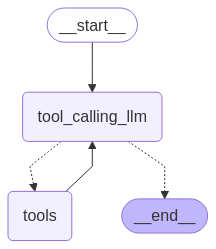

In [52]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
messages = graph.invoke({"messages": "What is the latest news on Ind Pak"})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the latest news on Ind Pak
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_t8sq)
 Call ID: call_t8sq
  Args:
    query: latest news on India Pakistan
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "India-Pakistan tensions continue to simmer across Kashmir border", "url": "https://www.aljazeera.com/news/2025/4/29/india-and-pakistan-tensions-continue-to-simmer-across-kashmir-border", "content": "Islamabad denies any role and has called for a neutral inquiry.\n\nA series of tit-for-tat diplomatic measures has followed, including the cancellation of visas and the recall of diplomats.\n\nIndia has shut its border with Pakistan and banished Pakistani citizens. Pakistan has announced border and airspace closures and threatened to ditch the 1972 Sim